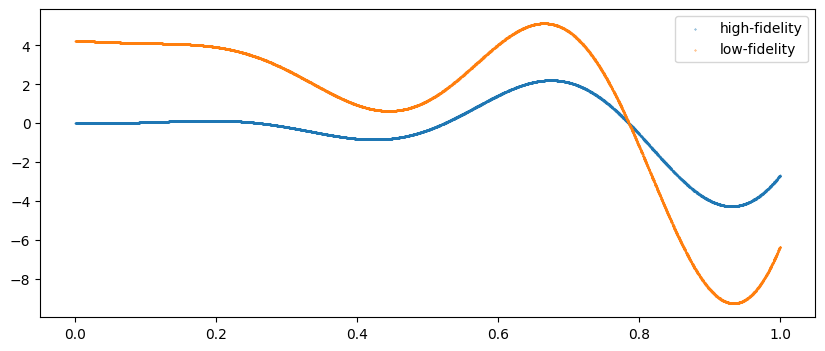

In [52]:
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm 
import math 

# LINEAR-B 
funcs = [
    lambda x: ((5*x**2) * np.sin(12*x)), 
    lambda x: (2*(5*x**2) * np.sin(12*x)+(x**3-0.5*np.sin(3*x-0.5))+4*np.cos(2*x))]

# Setting the minimum condition number
rcond = 1e-15

# Computing moments 
n_pilot = 10000 
z_pilot = np.random.uniform(0,1,n_pilot)

# Creating polynomial features and standard scaling 
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
scaler, features = StandardScaler(), PolynomialFeatures(degree=8)
X_pilot = scaler.fit_transform(features.fit_transform(z_pilot.reshape(-1,1)))
d = X_pilot.shape[1]

# Obtaining pilot samples for y1 and y2
y1_pilot = funcs[0](z_pilot)
y2_pilot = funcs[1](z_pilot)

# Computing means 
y1_mean = np.mean(y1_pilot)
y2_mean = np.mean(y2_pilot)

# Creating the variable w = x*y(x)
xy1_pilot = X_pilot.T * (y1_pilot - y1_mean).reshape(1,-1)
xy2_pilot = X_pilot.T * (y2_pilot - y2_mean).reshape(1,-1)

# Computing the moments 
Sigma_xx = np.cov(X_pilot.T)
Sigma_xy = np.cov(np.hstack((X_pilot, y1_pilot.reshape(-1,1))).T)[-1,:-1].T 
Sigma_xy1 = np.cov(xy1_pilot) # note these are variances of the product x*y_1(x), not the covariance between x and y1 
Sigma_xy2 = np.cov(xy2_pilot)
Sigma_xy12 = np.cov(np.vstack((xy1_pilot, xy2_pilot)))[:d, d:]
var_y1 = np.var(y1_pilot)
var_y2 = np.var(y2_pilot)
U, S, _ = np.linalg.svd(Sigma_xx) 
S = S[S / S[0] > rcond] # Truncating small singular values 
U = U[:,:S.shape[0]] # Truncating singular vectors 
Sigma_xx_inv = U @ np.diag(S**(-1)) @ U.T 
Sigma_xx_half_inv = U @ np.diag(S**(-0.5)) @ U.T 



plt.figure(figsize=(10,4))
plt.scatter(z_pilot, y1_pilot, label = "high-fidelity", s = 0.1)
plt.scatter(z_pilot, y2_pilot, label = "low-fidelity", s = 0.1)
plt.legend()

In [76]:
# Defining budget and cost parameters
B = 100
c1, c2 = 10, 0.05

In [77]:
# Verifying MSE approximation with 100% high-fidelity samples
n_1 = int(B / c1)
print("Using %d hf samples" % n_1)

# Setting number of trials 
n_trials = 25000
# Creating vector of Squared errors 
squared_errors = np.zeros(n_trials)
hf_preds = np.zeros((n_pilot, n_trials))

for i in range(n_trials):
    # Setting random seed
    # np.random.seed(i) 
    # Taking a random sample 
    z1 = np.random.uniform(0,1,n_1)
    # Creating polynomial features 
    X1 = scaler.transform(features.transform(z1.reshape(-1,1)))
    y1 = funcs[0](z1) 
    # Performing LSR with these inputs 
    mc_cov_xy = X1.T @ (y1 - y1_mean) / n_1
    # Solving for weights 
    w = Sigma_xx_inv @ mc_cov_xy
    # Making predictions 
    yhat = X_pilot @ w + y1_mean
    hf_preds[:,i] = yhat.ravel()
    # Storing the MSE 
    squared_errors[i] = np.mean((yhat - y1_pilot)**2)
    
# Printing final squared error
print(np.mean(squared_errors))
# Computing the theoretical mse 
mc_term = np.trace(Sigma_xx_inv @ Sigma_xy1) / n_1 
irreducible_term = var_y1 - Sigma_xy.T @ Sigma_xx_inv @ Sigma_xy
print(mc_term + irreducible_term)

Using 10 hf samples
2.4522794749960695
2.484056542774122


In [78]:
a = np.trace(Sigma_xx_inv @ Sigma_xy1) 
b = np.trace(Sigma_xx_inv @ Sigma_xy12 @ np.linalg.lstsq(Sigma_xy2, Sigma_xy12.T)[0])
n_1 = B * (c1 * (a-b) - np.sqrt(b * c1 * c2 * (a-b))) / (c1 * (c1 *(a-b) - b*c2))
n_2 = B * (-a * c1 * c2 + (c1 + c2) * np.sqrt(b * c1 * c2 *(a-b))) / (c1*c2*(a*c1 - b*(c1+c2)))
print(int(n_1), int(n_2))
print(n_1 * c1 + (n_1 + n_2) * c2)

6 656
100.00000000000026


In [79]:
n_1, n_2 = int(n_1), int(n_2)
# Setting the minimum condition number
rcond = 1e-13
# Setting number of trials 
n_trials = 10000
# Creating vector of Squared errors 
squared_errors = np.zeros(n_trials)
mf_preds = np.zeros((n_pilot, n_trials))

for i in range(n_trials):
    # Setting random seed
    # np.random.seed(i) 
    # Taking a random sample 
    z1 = np.random.uniform(0,1,n_1)
    z2 = np.random.uniform(0,1,n_2)
    # Creating polynomial features 
    X1 = scaler.transform(features.transform(z1.reshape(-1,1)))
    X2 = scaler.transform(features.transform(z2.reshape(-1,1)))
    y1_1 = funcs[0](z1)
    y2_2 = funcs[1](z2) 
    y2_1 = funcs[1](z1)
    # Computing optimal CV coefficient 
    A2 = n_2 / (n_1 + n_2) * Sigma_xx_half_inv @ Sigma_xy12 @ np.linalg.pinv(Sigma_xy2)
    # Computing estimate for q 
    q2_2 = A2 @ (X2.T @ (y2_2 - y2_mean)) / n_2 
    q2_1 = A2 @ (X1.T @ (y2_1 - y2_mean)) / n_1 
    q1_1 = Sigma_xx_half_inv @ (X1.T @ (y1_1 - y1_mean)) / n_1 
    q_hat = q2_2 + q1_1 - q2_1 
    # Solving for weights 
    w = Sigma_xx_half_inv @ q_hat 
    # Making predictions 
    yhat = X_pilot @ w + y1_mean 
    mf_preds[:,i] = yhat
    # Storing the MSE 
    squared_errors[i] = np.mean((yhat - y1_pilot)**2)
    
# Printing final squared error
print(np.mean(squared_errors))
mc_term = np.trace(Sigma_xx_inv @ (Sigma_xy1 - n_2 / (n_1 + n_2) * Sigma_xy12 @ np.linalg.lstsq(Sigma_xy2, Sigma_xy12.T)[0]) )/ n_1
print(mc_term + irreducible_term)

0.12293330482537035
0.12321589118122815


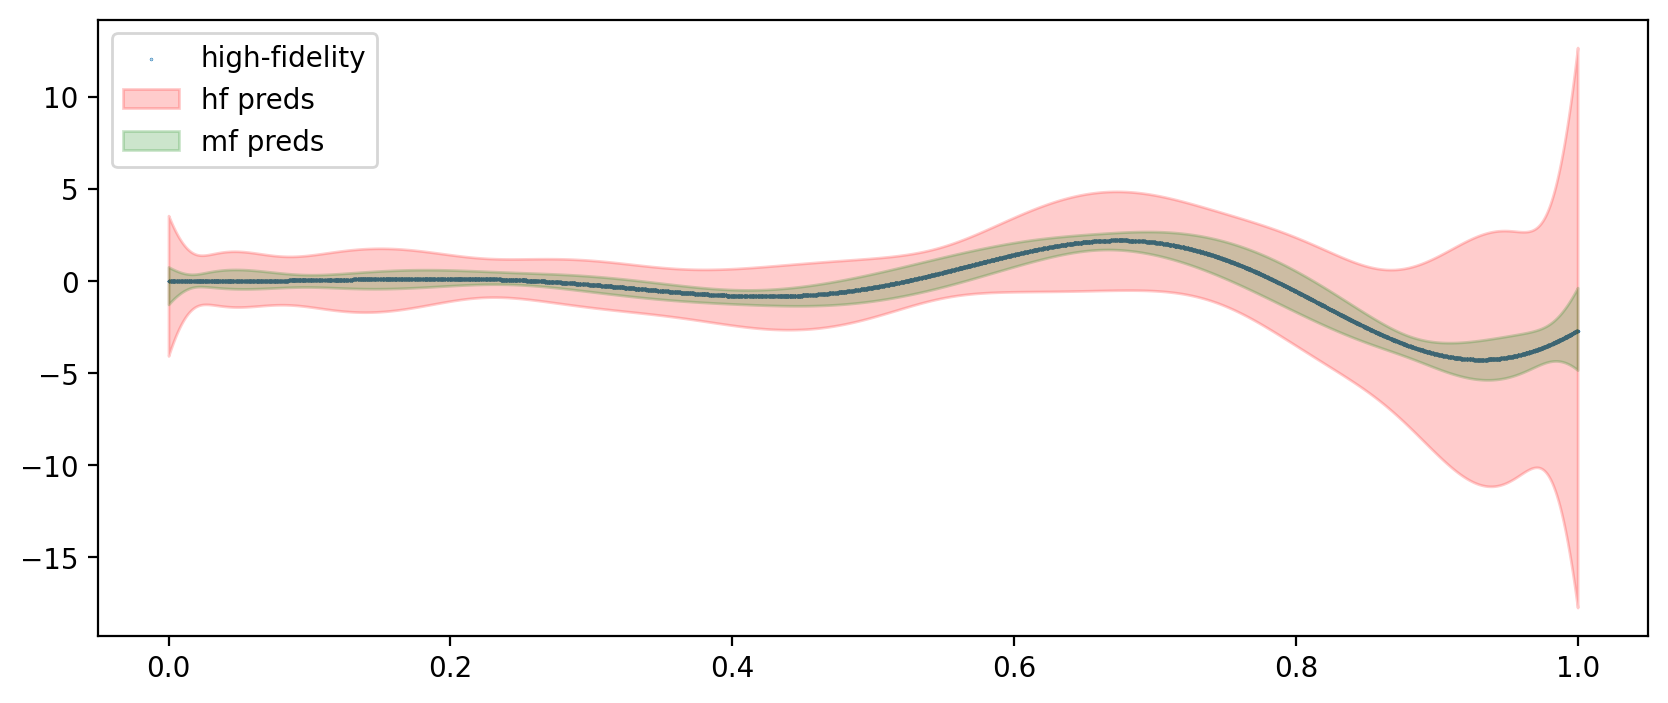

In [80]:
inds = np.argsort(z_pilot)
hf_mean, hf_two_sigma = hf_preds.mean(axis=1), 2*hf_preds.std(axis=1)
mf_mean, mf_two_sigma = mf_preds.mean(axis=1), 2*mf_preds.std(axis=1)
plt.figure(figsize=(10,4), dpi = 200)
plt.scatter(z_pilot, y1_pilot, label = "high-fidelity", s = 0.05)
plt.fill_between(z_pilot[inds], hf_mean[inds] - hf_two_sigma[inds], hf_mean[inds]+ hf_two_sigma[inds], color = 'red', alpha = 0.2, label = "hf preds")
plt.fill_between(z_pilot[inds], mf_mean[inds] - mf_two_sigma[inds], mf_mean[inds]+ mf_two_sigma[inds], color = 'green', alpha = 0.2, label = "mf preds")
plt.legend()